In [ ]:
# Investigating the Model() and trace object, observed datasets, prior and posterior.

In [1]:
import pymc as pm
import pytensor
import numpy as np

from IPython.core.pylabtools import figsize
import matplotlib.pyplot as plt
import scipy.stats as stats
import arviz as az

plt.style.use("ggplot")
RANDOM_SEED = 8927
rng = np.random.default_rng(RANDOM_SEED)

In [2]:
# generate data
mu = 0
sigma = 1
obs = stats.norm.rvs(loc=mu, scale=sigma)

In [3]:
# model without observed

with pm.Model() as model:
    mu = pm.Uniform('mu', -5, 5)
    sigma = pm.Uniform('sigma', .001, 3)
    dist = pm.Normal('dist', mu=mu, sigma=sigma)

    step = pm.Metropolis()
    trace = pm.sample(2000, step=step, chains=2, return_inferencedata=False)

Multiprocess sampling (2 chains in 2 jobs)
CompoundStep
>Metropolis: [mu]
>Metropolis: [sigma]
>Metropolis: [dist]


Output()

Sampling 2 chains for 1_000 tune and 2_000 draw iterations (2_000 + 4_000 draws total) took 0 seconds.
We recommend running at least 4 chains for robust computation of convergence diagnostics
The rhat statistic is larger than 1.01 for some parameters. This indicates problems during sampling. See https://arxiv.org/abs/1903.08008 for details
The effective sample size per chain is smaller than 100 for some parameters.  A higher number is needed for reliable rhat and ess computation. See https://arxiv.org/abs/1903.08008 for details


<function matplotlib.pyplot.show(close=None, block=None)>

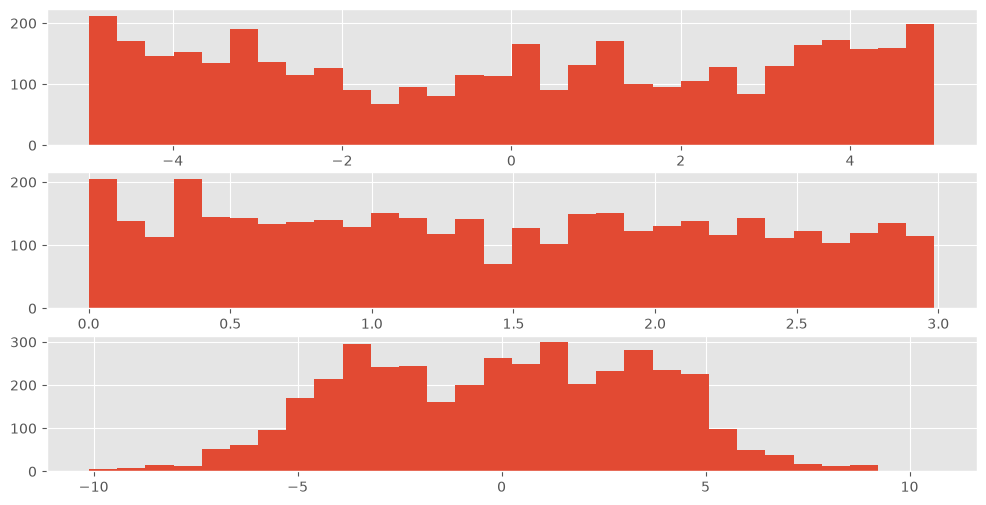

In [4]:
mu_samples = trace['mu']
sigma_samples = trace['sigma']
dist_samples = trace['dist']

figsize(12,6)

ax = plt.subplot(311)
plt.hist(mu_samples, bins=30)

ax = plt.subplot(312)
plt.hist(sigma_samples, bins=30)

ax = plt.subplot(313)
plt.hist(dist_samples, bins=30)

plt.show

# these are all just "priors" (?)


In [5]:
# model with observed

with pm.Model() as model:
    mu = pm.Uniform('mu', -5, 5)
    sigma = pm.Uniform('sigma', .01, 3)
    dist = pm.Normal('dist', mu=mu, sigma=sigma, observed=obs)

    step = pm.Metropolis()
    trace = pm.sample(2000, step=step, chains=2)

Multiprocess sampling (2 chains in 2 jobs)
CompoundStep
>Metropolis: [mu]
>Metropolis: [sigma]


Output()

Sampling 2 chains for 1_000 tune and 2_000 draw iterations (2_000 + 4_000 draws total) took 0 seconds.
We recommend running at least 4 chains for robust computation of convergence diagnostics


<function matplotlib.pyplot.show(close=None, block=None)>

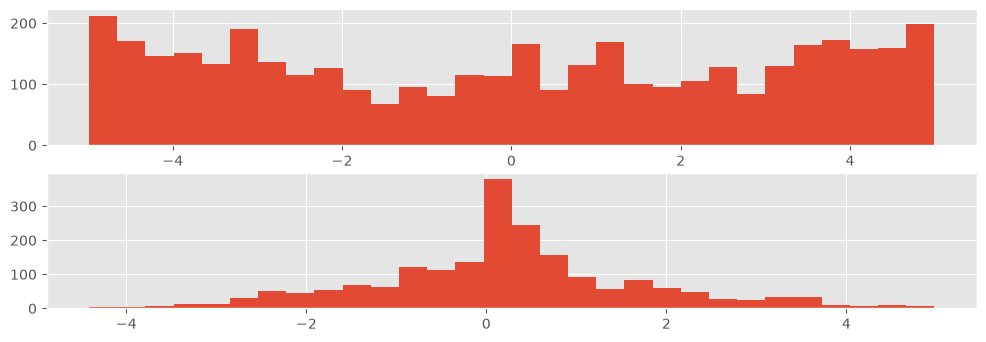

In [6]:
# mu - samples from uniform dist with and without observations provided
mu_samples_obs = np.concatenate(trace.posterior.mu.data[:,1000:])

figsize(12,6)
ax = plt.subplot(311)
plt.hist(mu_samples, bins=30)

ax = plt.subplot(312)
plt.hist(mu_samples_obs, bins=30)
plt.show

<function matplotlib.pyplot.show(close=None, block=None)>

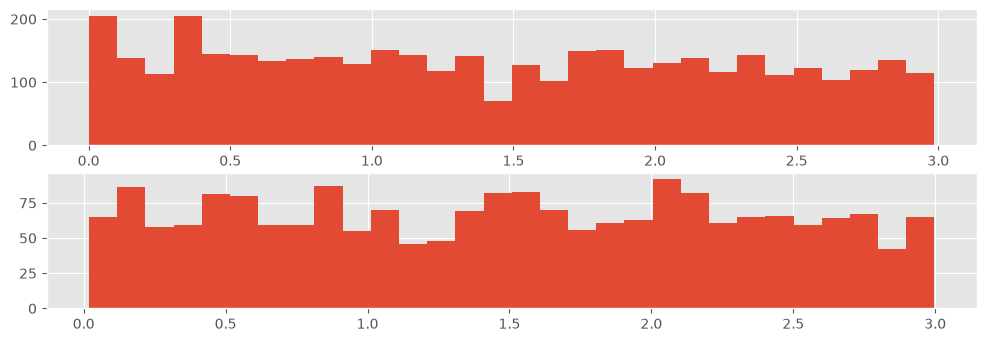

In [7]:
# sigma - samples from uniform dist with and without observations provided
sigma_samples_obs = np.concatenate(trace.posterior.sigma.data[:,1000:])

figsize(12,6)
ax = plt.subplot(311)
plt.hist(sigma_samples, bins=30)

ax = plt.subplot(312)
plt.hist(sigma_samples_obs, bins=30)
plt.show

array([[<Axes: title={'center': 'mu'}>, <Axes: title={'center': 'mu'}>],
       [<Axes: title={'center': 'sigma'}>,
        <Axes: title={'center': 'sigma'}>]], dtype=object)

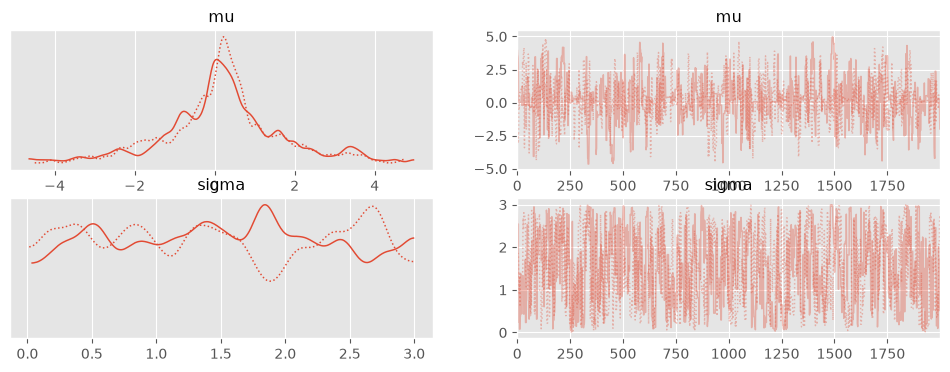

In [8]:
az.plot_trace(trace)